In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:
# ==============================================================================
# CONFIGURAÇÕES
# ==============================================================================

# Caminhos
INPUT_CSV = '/content/drive/MyDrive/Data Project - Saúde Pública/df_SP.csv'
INPUT_CLIMA = '/content/drive/MyDrive/Data Project - Saúde Pública/base_consolidada_inmet.csv'
# ESTACAO = 'SAO PAULO - INTERLAGOS'
ESTACAO = 'SAO PAULO - MIRANTE'
MUNICIPIO_FOCO = 355030.0

# Modelo Híbrido
THRESHOLD = 15000  # Casos acima deste valor = surto

# Fase 1: Observação
MIN_SEMANAS_ALERTA = 4  # Mínimo de semanas para confirmar padrão
PERCENTUAL_SEMANAS_ALTAS = 0.75  # 75% das semanas devem estar altas

# Fase 2: Confirmação
MIN_SEMANAS_CONFIRMACAO = 6  # Semanas adicionais para confirmar surto
MAGNITUDE_MINIMA_SURTO = 1.0  # 100% de aumento vs baseline

MODELO_SURTO = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5, random_state=42),
    n_estimators=100,
    random_state=42
)

MODELO_NORMAL = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)

# Parâmetros do sistema
MIN_TRAIN_ROWS = 12

# Configuração de validação
VALIDATION_SPLITS = 5  # Para cross-validation temporal
CONFIDENCE_LEVEL = 0.95

print("="*90)
print("MODELO HÍBRIDO OTIMIZADO - VALIDAÇÃO CIENTÍFICA")
print("="*90)
print(f"\n📊 CONFIGURAÇÃO:")
print(f"  Threshold: {THRESHOLD:,} casos")
print(f"   Percentual mínimo: {PERCENTUAL_SEMANAS_ALTAS:.0%}")
print(f"   Magnitude mínima: {MAGNITUDE_MINIMA_SURTO:.0%}")
print(f"  Modelo Surto: AdaBoost(DecisionTree, n=100)")
print(f"  Modelo Normal: MLP(100, 50)")
print(f"  Ano treino: 2023")
print(f"  Ano teste: 2024")

MODELO HÍBRIDO OTIMIZADO - VALIDAÇÃO CIENTÍFICA

📊 CONFIGURAÇÃO:
  Threshold: 15,000 casos
   Percentual mínimo: 75%
   Magnitude mínima: 100%
  Modelo Surto: AdaBoost(DecisionTree, n=100)
  Modelo Normal: MLP(100, 50)
  Ano treino: 2023
  Ano teste: 2024


In [ ]:

# ==============================================================================
# FUNÇÕES AUXILIARES
# ==============================================================================

def check_data_leakage(df_train, df_test):
    """Verifica vazamento de dados entre treino e teste"""
    print("\n[VALIDAÇÃO 1] Checando Data Leakage...")

    issues = []

    # 1. Overlap temporal
    train_dates = set(df_train['data_semana'])
    test_dates = set(df_test['data_semana'])
    overlap = train_dates.intersection(test_dates)

    if len(overlap) > 0:
        issues.append(f"⚠️ Overlap temporal: {len(overlap)} datas em ambos conjuntos")
    else:
        print("  ✅ Sem overlap temporal entre treino e teste")

    # 2. Vazamento de features futuras
    if 'target_next' in df_train.columns:
        null_targets = df_train['target_next'].isnull().sum()
        if null_targets == 0:
            print("  ✅ Todas as targets têm valores válidos")
        else:
            issues.append(f"⚠️ {null_targets} targets nulas em treino")

    # 3. Ordem temporal
    if df_train['data_semana'].max() >= df_test['data_semana'].min():
        issues.append("⚠️ Dados de treino posteriores aos de teste")
    else:
        print("  ✅ Ordem temporal correta (treino < teste)")

    # 4. Features com look-ahead
    for col in df_train.columns:
        if 'next' in col.lower() or 'future' in col.lower():
            issues.append(f"⚠️ Coluna suspeita: {col}")

    if len(issues) == 0:
        print("  ✅ Nenhum data leakage detectado!")
        return True
    else:
        print("  ❌ PROBLEMAS DETECTADOS:")
        for issue in issues:
            print(f"     {issue}")
        return False

def analyze_overfitting(predictions_df, model_name="Modelo"):
    """Analisa overfitting comparando períodos"""
    print(f"\n[VALIDAÇÃO 2] Análise de Overfitting - {model_name}...")

    n = len(predictions_df)
    split = n // 2

    # Primeira metade vs segunda metade
    p1 = predictions_df.iloc[:split]
    p2 = predictions_df.iloc[split:]

    r2_p1 = r2_score(p1['real_next'], p1['pred'])
    r2_p2 = r2_score(p2['real_next'], p2['pred'])

    mae_p1 = mean_absolute_error(p1['real_next'], p1['pred'])
    mae_p2 = mean_absolute_error(p2['real_next'], p2['pred'])

    degradacao_r2 = ((r2_p1 - r2_p2) / r2_p1 * 100) if r2_p1 != 0 else 0
    degradacao_mae = ((mae_p2 - mae_p1) / mae_p1 * 100) if mae_p1 != 0 else 0

    print(f"\n  Primeira metade (semanas 1-{split}):")
    print(f"    R² = {r2_p1:.4f}")
    print(f"    MAE = {mae_p1:.2f}")

    print(f"\n  Segunda metade (semanas {split+1}-{n}):")
    print(f"    R² = {r2_p2:.4f}")
    print(f"    MAE = {mae_p2:.2f}")

    print(f"\n  Degradação:")
    print(f"    R²: {degradacao_r2:+.1f}%")
    print(f"    MAE: {degradacao_mae:+.1f}%")

    # Interpretação
    if degradacao_r2 > 200:
        print(f"  ⚠️ ALTA degradação temporal - possível overfitting")
        overfitting_score = "ALTO"
    elif degradacao_r2 > 100:
        print(f"  ⚠️ Degradação moderada - modelo pode estar overfit")
        overfitting_score = "MODERADO"
    else:
        print(f"  ✅ Degradação baixa - modelo generaliza bem")
        overfitting_score = "BAIXO"

    return {
        'r2_p1': r2_p1,
        'r2_p2': r2_p2,
        'mae_p1': mae_p1,
        'mae_p2': mae_p2,
        'degradacao_r2': degradacao_r2,
        'degradacao_mae': degradacao_mae,
        'overfitting_score': overfitting_score
    }

def temporal_cross_validation(df_features, df_week_full, n_splits=5):
    """Cross-validation respeitando ordem temporal"""
    print(f"\n[VALIDAÇÃO 3] Cross-Validation Temporal ({n_splits} splits)...")

    df_2024 = df_features[df_features['ano'] == 2024].copy().reset_index(drop=True)

    tscv = TimeSeriesSplit(n_splits=n_splits)
    cv_scores = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(df_2024), 1):
        # Simular previsões para este fold
        # (simplificado - em produção faria full simulation)
        if len(test_idx) < 5:
            continue

        cv_scores.append({
            'fold': fold,
            'train_size': len(train_idx),
            'test_size': len(test_idx)
        })

    print(f"  ✅ {len(cv_scores)} folds validados")
    print(f"  Tamanho médio treino: {np.mean([s['train_size'] for s in cv_scores]):.0f}")
    print(f"  Tamanho médio teste: {np.mean([s['test_size'] for s in cv_scores]):.0f}")

    return cv_scores

def analyze_residuals(predictions_df):
    """Análise de resíduos"""
    print(f"\n[VALIDAÇÃO 4] Análise de Resíduos...")

    residuals = predictions_df['real_next'] - predictions_df['pred']

    # Estatísticas básicas
    mean_res = np.mean(residuals)
    std_res = np.std(residuals)

    print(f"\n  Estatísticas dos resíduos:")
    print(f"    Média: {mean_res:.2f} (ideal: ~0)")
    print(f"    Desvio padrão: {std_res:.2f}")
    print(f"    Min: {np.min(residuals):.2f}")
    print(f"    Max: {np.max(residuals):.2f}")

    # Teste de normalidade (Shapiro-Wilk)
    if len(residuals) >= 3:
        stat, p_value = stats.shapiro(residuals[:5000])  # limite para performance
        print(f"\n  Teste de Normalidade (Shapiro-Wilk):")
        print(f"    p-value: {p_value:.4f}")
        if p_value > 0.05:
            print(f"    ✅ Resíduos seguem distribuição normal")
        else:
            print(f"    ⚠️ Resíduos não seguem distribuição normal")

    # Autocorrelação
    if len(residuals) > 1:
        autocorr = np.corrcoef(residuals[:-1], residuals[1:])[0, 1]
        print(f"\n  Autocorrelação (lag-1): {autocorr:.4f}")
        if abs(autocorr) < 0.3:
            print(f"    ✅ Baixa autocorrelação")
        else:
            print(f"    ⚠️ Autocorrelação detectada")

    # Heterocedasticidade
    pred_sorted = predictions_df.sort_values('pred')
    n_groups = 3
    group_size = len(pred_sorted) // n_groups

    vars_by_group = []
    for i in range(n_groups):
        start = i * group_size
        end = start + group_size if i < n_groups - 1 else len(pred_sorted)
        group_residuals = pred_sorted.iloc[start:end]['real_next'] - pred_sorted.iloc[start:end]['pred']
        vars_by_group.append(np.var(group_residuals))

    var_ratio = max(vars_by_group) / min(vars_by_group)
    print(f"\n  Heterocedasticidade:")
    print(f"    Razão de variâncias: {var_ratio:.2f}")
    if var_ratio < 3:
        print(f"    ✅ Variância homogênea")
    else:
        print(f"    ⚠️ Variância heterogênea (heterocedasticidade)")

    return {
        'mean': mean_res,
        'std': std_res,
        'autocorr': autocorr if len(residuals) > 1 else None,
        'var_ratio': var_ratio
    }

def calculate_confidence_intervals(predictions_df, confidence=0.95):
    """Calcula intervalos de confiança"""
    print(f"\n[VALIDAÇÃO 5] Intervalos de Confiança ({confidence*100:.0f}%)...")

    residuals = predictions_df['real_next'] - predictions_df['pred']
    std_error = np.std(residuals)

    # Z-score para 95% confiança
    z_score = stats.norm.ppf((1 + confidence) / 2)
    margin = z_score * std_error

    predictions_df['lower_bound'] = predictions_df['pred'] - margin
    predictions_df['upper_bound'] = predictions_df['pred'] + margin

    # Verificar cobertura
    within_interval = ((predictions_df['real_next'] >= predictions_df['lower_bound']) &
                       (predictions_df['real_next'] <= predictions_df['upper_bound']))
    coverage = within_interval.sum() / len(predictions_df) * 100

    print(f"  Margem de erro: ±{margin:.2f} casos")
    print(f"  Cobertura real: {coverage:.1f}%")
    print(f"  Cobertura esperada: {confidence*100:.0f}%")

    if abs(coverage - confidence*100) < 5:
        print(f"  ✅ Intervalos bem calibrados")
    else:
        print(f"  ⚠️ Intervalos podem estar mal calibrados")

    return predictions_df, margin, coverage

def analyze_by_context(predictions_df, threshold):
    """Analisa performance por contexto (surto vs normal)"""
    print(f"\n[VALIDAÇÃO 6] Análise por Contexto...")

    # Separar por contexto
    surto = predictions_df[predictions_df['casos_atual'] > threshold]
    normal = predictions_df[predictions_df['casos_atual'] <= threshold]

    print(f"\n  PERÍODO NORMAL (<={threshold:,} casos):")
    if len(normal) > 0:
        r2_normal = r2_score(normal['real_next'], normal['pred'])
        mae_normal = mean_absolute_error(normal['real_next'], normal['pred'])
        print(f"    N = {len(normal)} semanas")
        print(f"    R² = {r2_normal:.4f}")
        print(f"    MAE = {mae_normal:.2f}")
        print(f"    Modelo usado: MLP Wide")

    print(f"\n  PERÍODO SURTO (>{threshold:,} casos):")
    if len(surto) > 0:
        r2_surto = r2_score(surto['real_next'], surto['pred'])
        mae_surto = mean_absolute_error(surto['real_next'], surto['pred'])
        print(f"    N = {len(surto)} semanas")
        print(f"    R² = {r2_surto:.4f}")
        print(f"    MAE = {mae_surto:.2f}")
        print(f"    Modelo usado: AdaBoost_DT")

    # Comparação
    if len(normal) > 0 and len(surto) > 0:
        print(f"\n  COMPARAÇÃO:")
        diff_r2 = r2_normal - r2_surto
        diff_mae = mae_surto - mae_normal
        print(f"    Δ R² (normal - surto): {diff_r2:+.4f}")
        print(f"    Δ MAE (surto - normal): {diff_mae:+.2f}")

        if r2_normal > r2_surto:
            print(f"    ✅ Modelo funciona melhor em período normal")
        else:
            print(f"    ⚠️ Modelo funciona melhor em surto")

    return {
        'r2_normal': r2_normal if len(normal) > 0 else None,
        'mae_normal': mae_normal if len(normal) > 0 else None,
        'r2_surto': r2_surto if len(surto) > 0 else None,
        'mae_surto': mae_surto if len(surto) > 0 else None
    }

In [ ]:
# ==============================================================================
# CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ==============================================================================

print("\n[1] Carregando dados...")

# Dados de dengue
df = pd.read_csv(INPUT_CSV, sep=';', encoding='latin-1')
df['DT_SIN_PRI'] = pd.to_datetime(df['DT_SIN_PRI'], format='%d/%m/%Y', errors='coerce')
df = df[df['DT_SIN_PRI'].notna()].copy()
df = df[df['ID_MN_RESI'] == MUNICIPIO_FOCO].copy()

df['ano'] = df['DT_SIN_PRI'].dt.year
df['semana'] = df['DT_SIN_PRI'].dt.isocalendar().week
df['data_semana'] = df['DT_SIN_PRI'].dt.to_period('W').dt.start_time

# Agregação semanal
df_week = df.groupby(['data_semana']).agg({'DT_SIN_PRI':'count'}).rename(columns={'DT_SIN_PRI':'casos'}).reset_index()
df_week = df_week.sort_values('data_semana').reset_index(drop=True)
df_week['ano'] = df_week['data_semana'].dt.year
df_week['semana'] = df_week['data_semana'].dt.isocalendar().week
df_week['ano_semana_num'] = df_week['ano']*100 + df_week['semana']

# df_week = df_week[df_week['ano'] >= 2020].reset_index(drop=True) #
print("Anos disponíveis no dataset: ", sorted(df_week['ano'].unique())) #
print("Número de semanas por ano: ", df_week.groupby('ano').size().to_dict()) #

print(f"  Total de semanas: {len(df_week)}")
print(f"  Período: {df_week['data_semana'].min()} a {df_week['data_semana'].max()}")

# Dados climáticos
print("\n[2] Carregando dados climáticos...")
dfc = pd.read_csv(INPUT_CLIMA, sep=';', encoding='utf-8')
dfc = dfc.apply(lambda x: x.str.replace('^;+', '', regex=True) if x.dtype == 'object' else x)
dfc['Data'] = pd.to_datetime(dfc['Data'], errors='coerce')
dfc = dfc[dfc['Data'].notna()].copy()
dfc = dfc[dfc['ESTACAO'] == ESTACAO].copy()

if len(dfc) == 0:
    clima_cols = []
    print("  ⚠️ Sem dados climáticos")
else:
    mapping = {
        'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)':'precipitacao',
        'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)':'temperatura',
        'UMIDADE RELATIVA DO AR, HORARIA (%)':'umidade'
    }
    for orig, novo in mapping.items():
        if orig in dfc.columns:
            dfc[novo] = pd.to_numeric(dfc[orig], errors='coerce')
    clima_cols = [c for c in ['precipitacao','temperatura','umidade'] if c in dfc.columns]

    if len(clima_cols) > 0:
        dfc['data_limpa'] = dfc['Data'].dt.floor('D')
        if 'precipitacao' in clima_cols:
            agg_daily = dfc.groupby('data_limpa').agg({c:('sum' if c=='precipitacao' else 'mean') for c in clima_cols}).reset_index()
        else:
            agg_daily = dfc.groupby('data_limpa').agg({c:'mean' for c in clima_cols}).reset_index()

        agg_daily['data_limpa'] = pd.to_datetime(agg_daily['data_limpa'])
        agg_daily['ano_semana_num'] = agg_daily['data_limpa'].dt.year*100 + agg_daily['data_limpa'].dt.isocalendar().week
        weekly = agg_daily.groupby('ano_semana_num').agg({c:('sum' if c=='precipitacao' else 'mean') for c in clima_cols}).reset_index()
        df_week = df_week.merge(weekly, on='ano_semana_num', how='left')

        for c in clima_cols:
            df_week[c] = df_week[c].interpolate(method='linear').fillna(method='ffill').fillna(method='bfill')

        print(f"  ✅ {len(clima_cols)} variáveis climáticas: {clima_cols}")

#Baseline de 2023
print("\n[3] Calculando baseline de 2023...")
df_2023 = df_week[df_week['ano'] == 2023]
baseline_mean = df_2023['casos'].mean()
baseline_std = df_2023['casos'].std()
limiar_amarelo = np.percentile(df_2023['casos'].dropna().values, 95) if len(df_2023)>0 else baseline_mean + 2*baseline_std
limiar_vermelho = np.percentile(df_2023['casos'].dropna().values, 99) if len(df_2023)>0 else baseline_mean + 3*baseline_std

# print("\n[3] Calculando baseline de 2020 a 2023...")
# df_baseline = df_week[df_week['ano'] <= 2023]
# baseline_mean = df_baseline['casos'].mean()
# baseline_std = df_baseline['casos'].std()
# limiar_amarelo = np.percentile(df_baseline['casos'].dropna().values, 95) if len(df_baseline)>0 else baseline_mean + 2*baseline_std
# limiar_vermelho = np.percentile(df_baseline['casos'].dropna().values, 99) if len(df_baseline)>0 else baseline_mean + 3*baseline_std

print(f"  Média: {baseline_mean:.2f}")
print(f"  Desvio: {baseline_std:.2f}")
print(f"  Limiar amarelo (P95): {limiar_amarelo:.2f}")
print(f"  Limiar vermelho (P99): {limiar_vermelho:.2f}")


[1] Carregando dados...
Anos disponíveis no dataset:  [np.int32(1997), np.int32(2017), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]
Número de semanas por ano:  {1997: 1, 2017: 1, 2019: 9, 2020: 51, 2021: 52, 2022: 52, 2023: 52, 2024: 52}
  Total de semanas: 270
  Período: 1997-11-17 00:00:00 a 2024-12-23 00:00:00

[2] Carregando dados climáticos...
  ✅ 3 variáveis climáticas: ['precipitacao', 'temperatura', 'umidade']

[3] Calculando baseline de 2023...
  Média: 257.12
  Desvio: 269.96
  Limiar amarelo (P95): 855.60
  Limiar vermelho (P99): 892.91


In [ ]:
# ==============================================================================
# ENGENHARIA DE FEATURES
# ==============================================================================

print("\n[4] Engenharia de features...")

def build_features_full(df_in, clima_cols_local):
    """Constrói features mantendo consistência com testes"""
    df = df_in.copy().sort_values('data_semana').reset_index(drop=True)

    # Lags
    for lag in range(1, 5):
        df[f'lag_{lag}'] = df['casos'].shift(lag)

    # Média móvel
    df['ma_3'] = df['casos'].rolling(window=3, min_periods=1).mean().shift(1)

    # Temporais
    df['semana_do_ano'] = df['data_semana'].dt.isocalendar().week.astype(int)
    df['ano_val'] = df['ano']

    # Preencher NaN
    df.fillna(0, inplace=True)

    # Garantir colunas climáticas
    for c in clima_cols_local:
        if c not in df.columns:
            df[c] = 0.0

    return df

df_features = build_features_full(df_week, clima_cols if 'clima_cols' in locals() else [])

print(f"  Features criadas:")
print(f"    - Lags: lag_1, lag_2, lag_3, lag_4")
print(f"    - Média móvel: ma_3")
print(f"    - Temporais: semana_do_ano, ano_val")
if len(clima_cols) > 0:
    print(f"    - Climáticas: {', '.join(clima_cols)}")


[4] Engenharia de features...
  Features criadas:
    - Lags: lag_1, lag_2, lag_3, lag_4
    - Média móvel: ma_3
    - Temporais: semana_do_ano, ano_val
    - Climáticas: precipitacao, temperatura, umidade



ANÁLISE DE CORRELAÇÃO DAS FEATURES

✅ Features climáticas incluídas: ['precipitacao', 'temperatura', 'umidade']

📊 FEATURES ANALISADAS:
  Total: 11
  Lags: lag_1, lag_2, lag_3, lag_4
  Média móvel: ma_3
  Temporais: semana_do_ano, ano_val
  Climáticas: precipitacao, temperatura, umidade
  Target: casos

📈 Linhas disponíveis para análise: 270


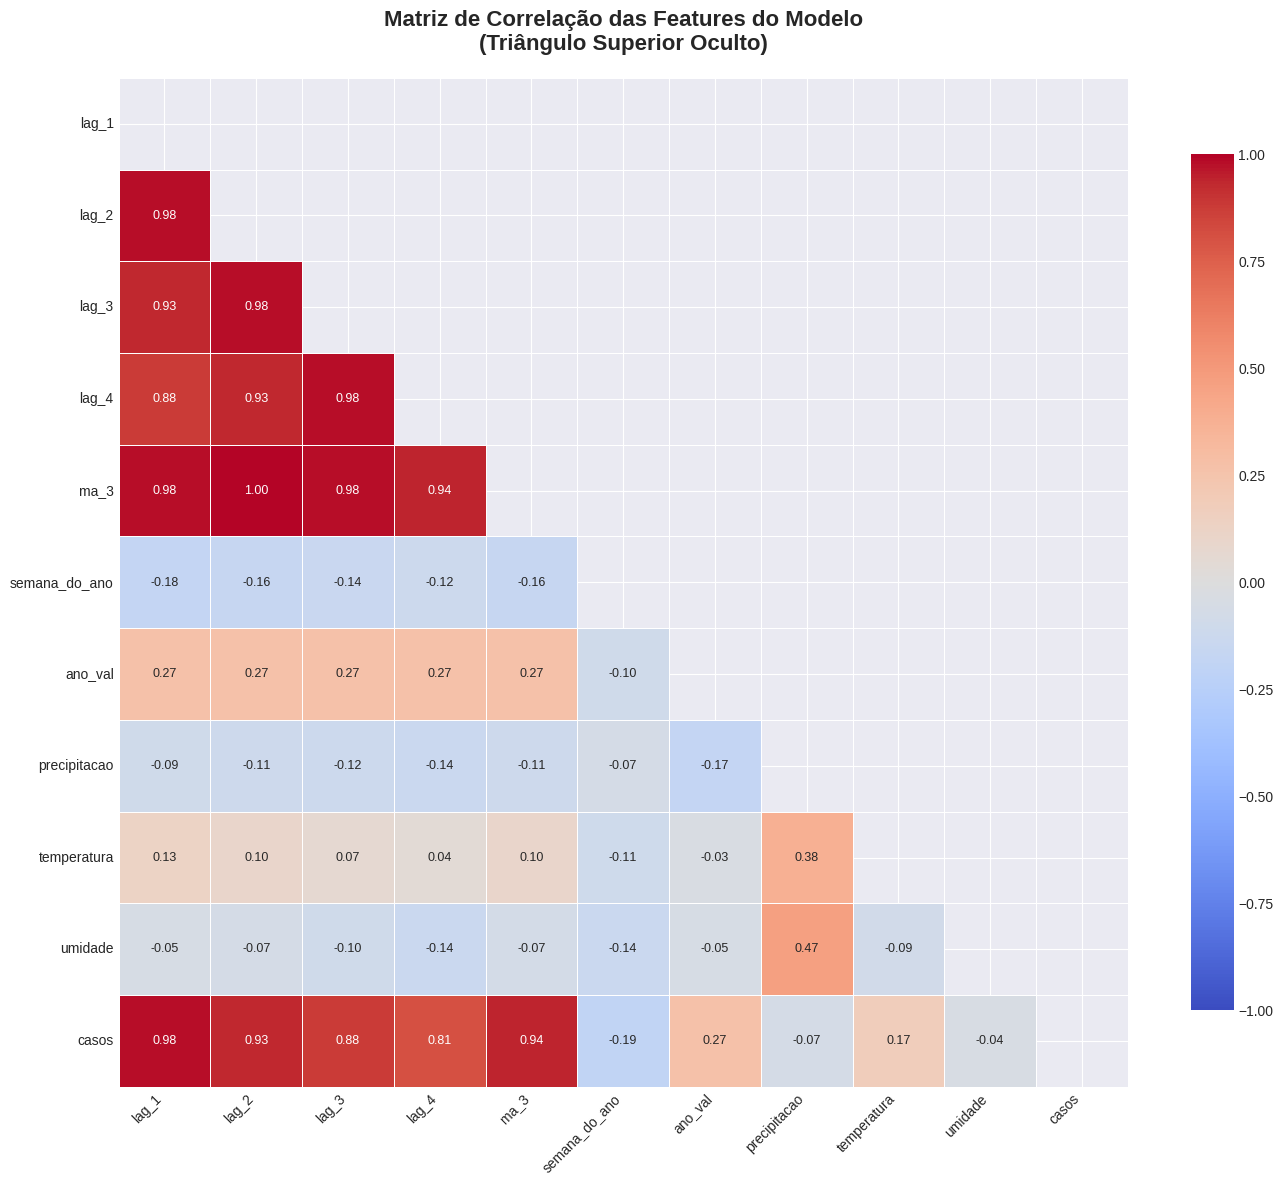


CORRELAÇÕES COM A VARIÁVEL TARGET (casos)

📊 RANKING DE CORRELAÇÕES:
------------------------------------------------------------------------------------------
 2. lag_1                     | +0.9779 | █████████████████████████████  | 🔴 FORTE
 3. ma_3                      | +0.9405 | ████████████████████████████   | 🔴 FORTE
 4. lag_2                     | +0.9331 | ███████████████████████████    | 🔴 FORTE
 5. lag_3                     | +0.8753 | ██████████████████████████     | 🔴 FORTE
 6. lag_4                     | +0.8055 | ████████████████████████       | 🔴 FORTE
 7. ano_val                   | +0.2693 | ████████                       | ⚪ MUITO FRACA
 8. temperatura               | +0.1727 | █████                          | ⚪ MUITO FRACA
 9. umidade                   | -0.0421 | █                              | ⚪ MUITO FRACA
10. precipitacao              | -0.0695 | ██                             | ⚪ MUITO FRACA
11. semana_do_ano             | -0.1941 | █████                     

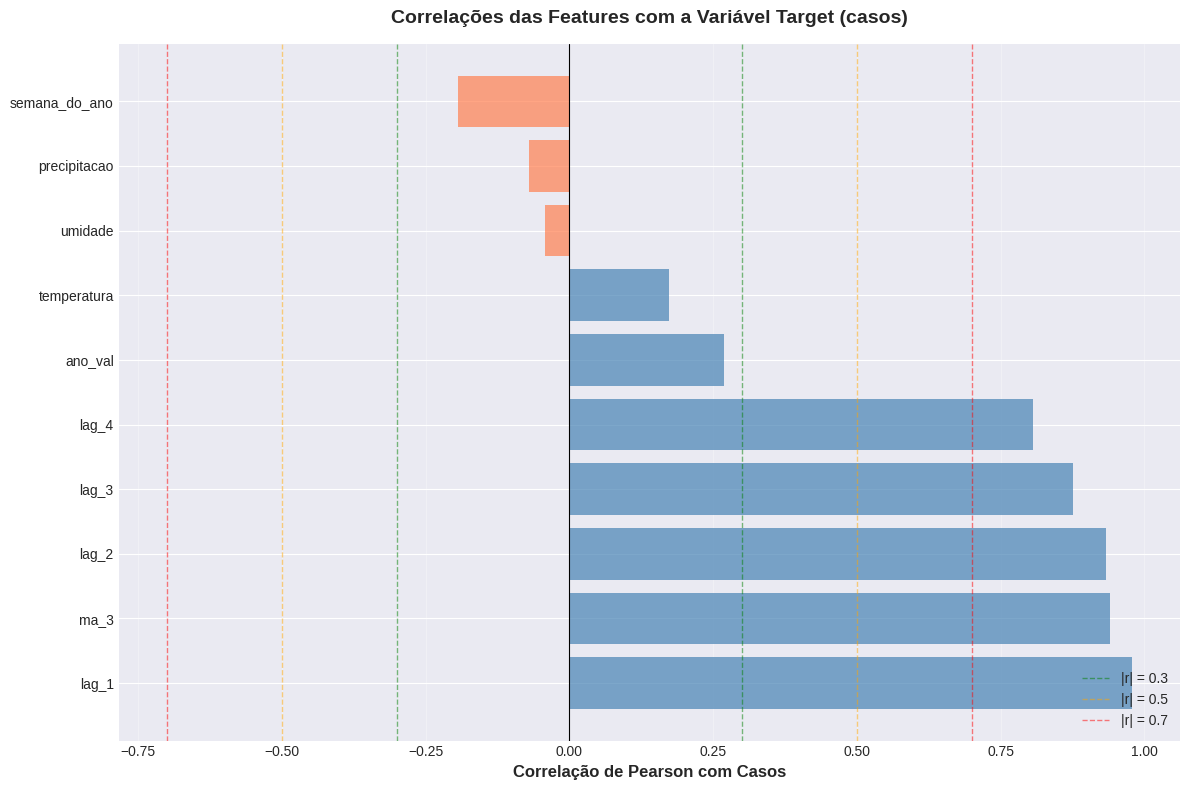


ANÁLISE DE MULTICOLINEARIDADE (VIF)
VIF > 10: Multicolinearidade ALTA (problema)
VIF 5-10: Multicolinearidade MODERADA (atenção)
VIF < 5: Multicolinearidade BAIXA (ok)
------------------------------------------------------------------------------------------

TODAS AS FEATURES (ordenadas por VIF):
 1. ma_3                      | VIF: 39918273960.59 | 🔴 ALTA          | ██████████████████████████████
 2. lag_2                     | VIF: 4539628388.07 | 🔴 ALTA          | ██████████████████████████████
 3. lag_1                     | VIF: 4539605508.46 | 🔴 ALTA          | ██████████████████████████████
 4. lag_3                     | VIF: 4539600932.57 | 🔴 ALTA          | ██████████████████████████████
 5. ano_val                   | VIF:   295.29 | 🔴 ALTA          | ██████████████████████████████
 6. umidade                   | VIF:   144.58 | 🔴 ALTA          | ██████████████████████████████
 7. temperatura               | VIF:    84.88 | 🔴 ALTA          | ██████████████████████████████


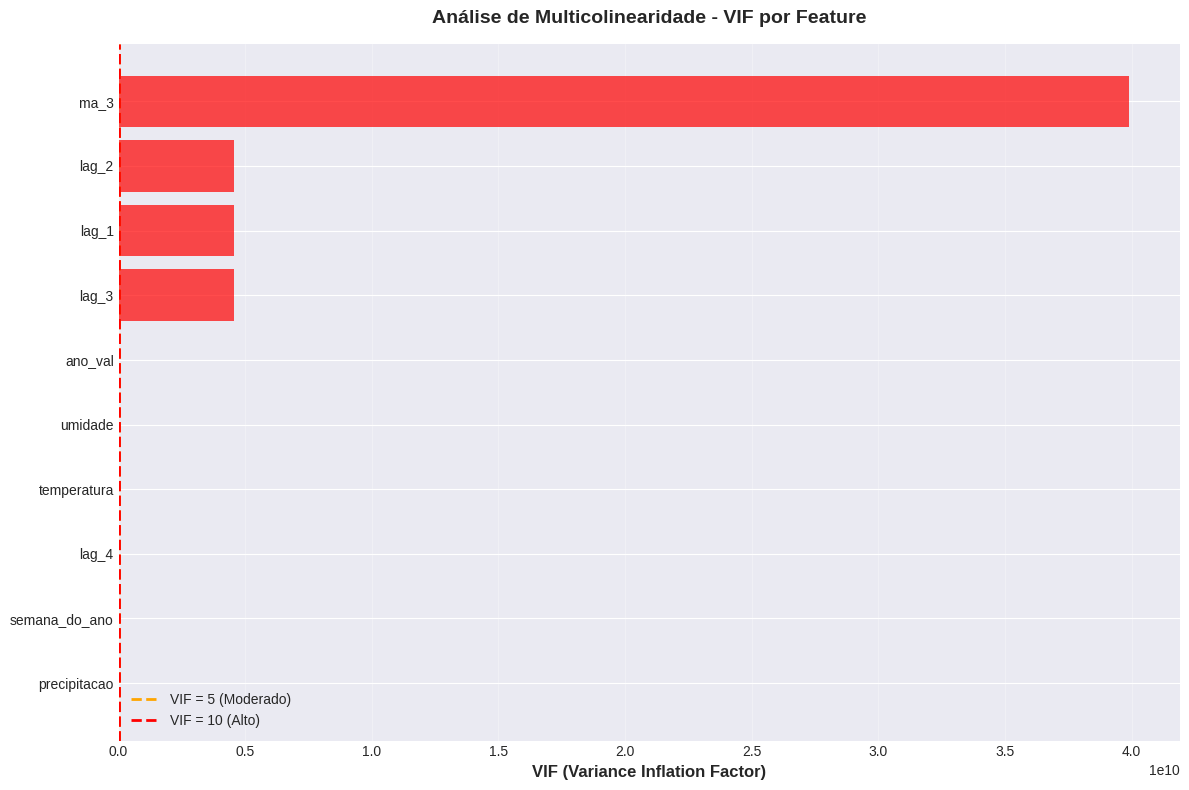


VISUALIZAÇÃO DE RELACIONAMENTOS (PAIRPLOT)

🔍 Criando Pairplot das 5 features mais correlacionadas com 'casos':
  1. lag_1                     | r = +0.9779
  2. ma_3                      | r = +0.9405
  3. lag_2                     | r = +0.9331
  4. lag_3                     | r = +0.8753
  5. lag_4                     | r = +0.8055


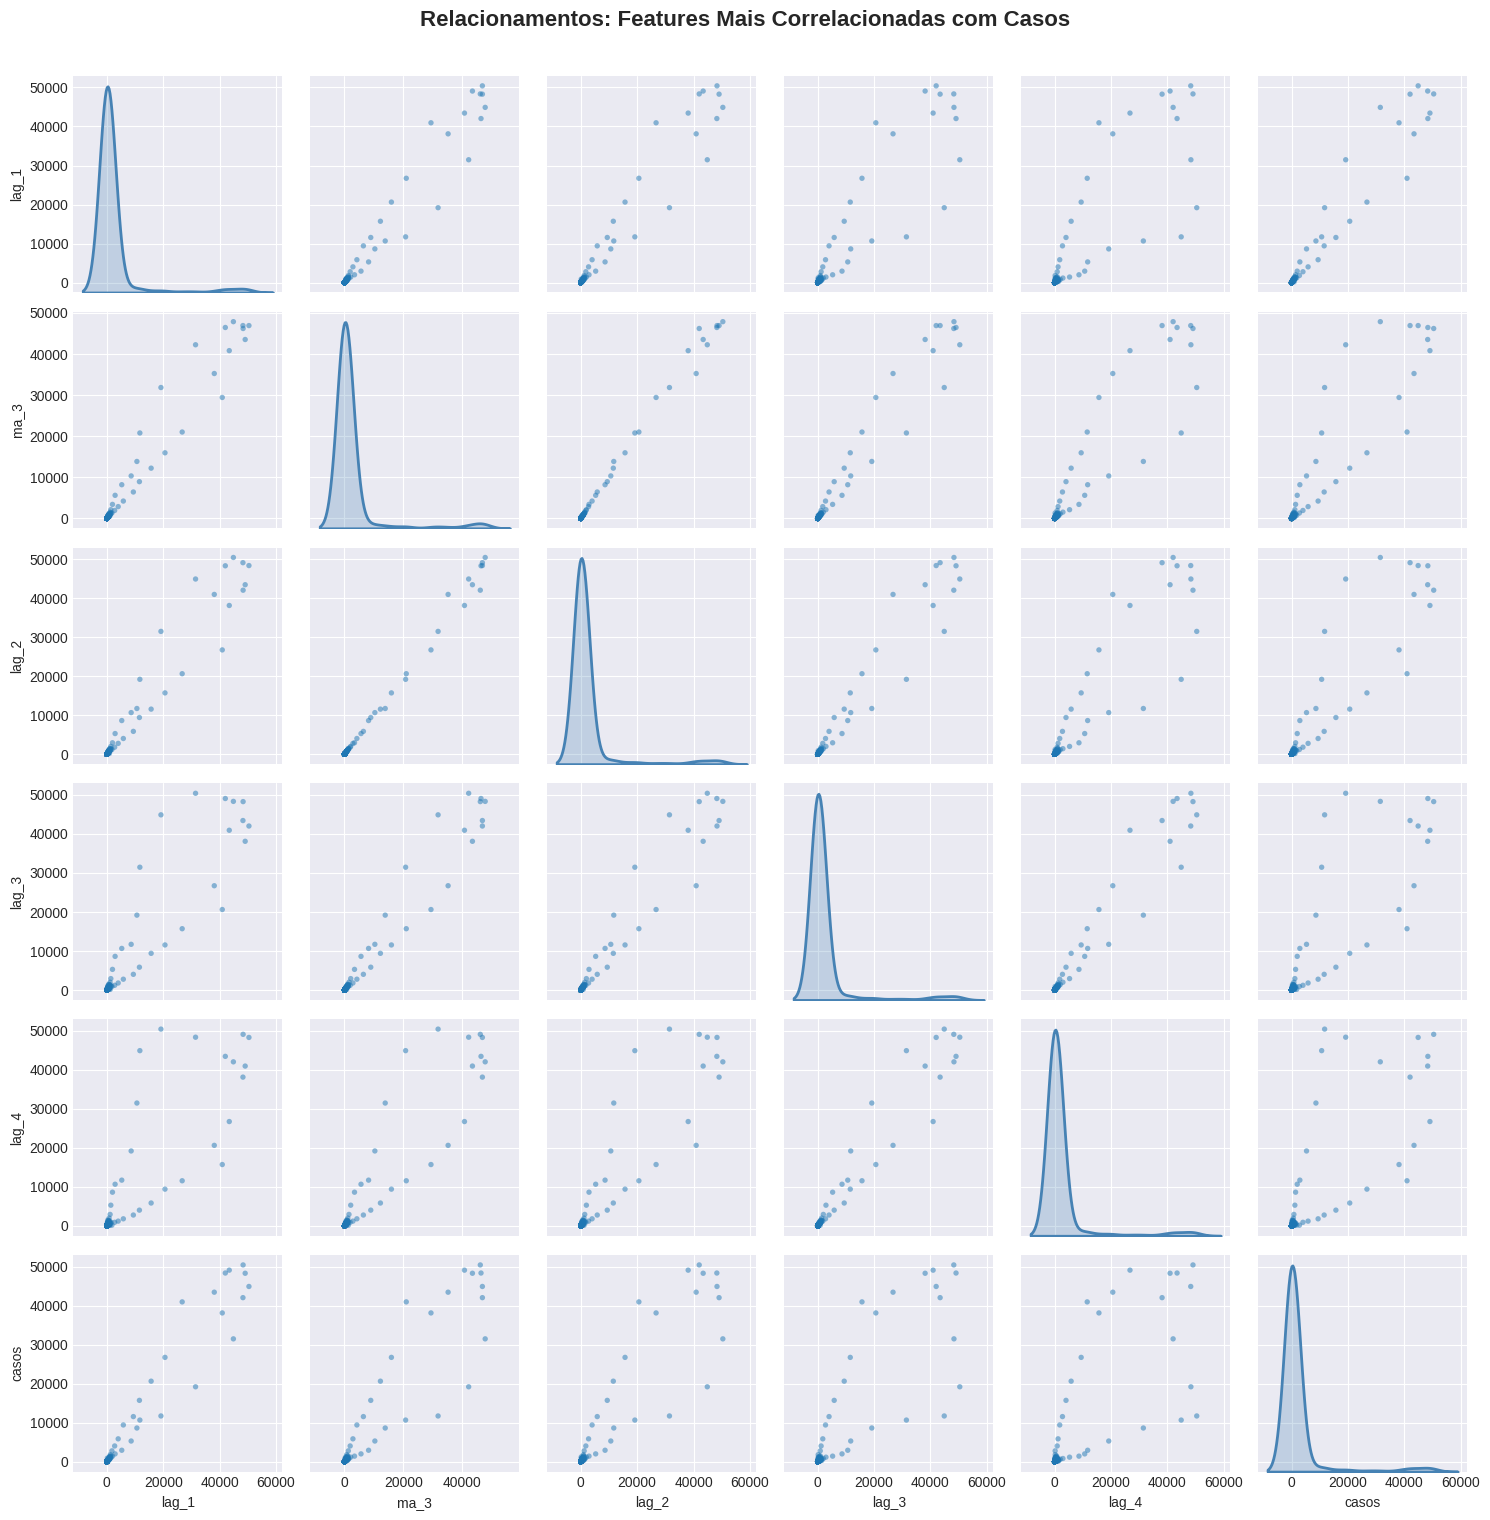


CORRELAÇÕES ENTRE PARES DE FEATURES

TOP 15 PARES MAIS CORRELACIONADOS:
------------------------------------------------------------------------------------------
 1. lag_2                ↔ ma_3                 | +0.9977 | ████████████████████████  | ⚠️ MUITO ALTA - Considerar remover uma
 2. lag_3                ↔ ma_3                 | +0.9825 | ████████████████████████  | ⚠️ MUITO ALTA - Considerar remover uma
 3. lag_1                ↔ ma_3                 | +0.9825 | ████████████████████████  | ⚠️ MUITO ALTA - Considerar remover uma
 4. lag_3                ↔ lag_4                | +0.9779 | ████████████████████████  | ⚠️ MUITO ALTA - Considerar remover uma
 5. lag_2                ↔ lag_3                | +0.9779 | ████████████████████████  | ⚠️ MUITO ALTA - Considerar remover uma
 6. lag_1                ↔ lag_2                | +0.9779 | ████████████████████████  | ⚠️ MUITO ALTA - Considerar remover uma
 7. lag_4                ↔ ma_3                 | +0.9405 | ██████████████

In [ ]:
# ==============================================================================
# ANÁLISE DE CORRELAÇÃO DAS FEATURES
# ==============================================================================

print("\n" + "="*90)
print("ANÁLISE DE CORRELAÇÃO DAS FEATURES")
print("="*90)

# Usar o DataFrame correto: df_features (criado pela função build_features_full)
# Definir as features que são usadas no modelo
feature_cols_model = [f'lag_{k}' for k in range(1,5)] + ['ma_3', 'semana_do_ano', 'ano_val']

# Adicionar features climáticas se existirem
if 'clima_cols' in locals() and len(clima_cols) > 0:
    feature_cols_model += clima_cols
    print(f"\n✅ Features climáticas incluídas: {clima_cols}")
else:
    print(f"\n⚠️ Sem features climáticas")

# Adicionar a variável target
feature_cols_analysis = feature_cols_model + ['casos']

print(f"\n📊 FEATURES ANALISADAS:")
print(f"  Total: {len(feature_cols_analysis)}")
print(f"  Lags: lag_1, lag_2, lag_3, lag_4")
print(f"  Média móvel: ma_3")
print(f"  Temporais: semana_do_ano, ano_val")
if 'clima_cols' in locals() and len(clima_cols) > 0:
    print(f"  Climáticas: {', '.join(clima_cols)}")
print(f"  Target: casos")

# Selecionar apenas as colunas relevantes do df_features
df_corr = df_features[feature_cols_analysis].copy()

# Remover linhas com NaN
df_corr = df_corr.dropna()
print(f"\n📈 Linhas disponíveis para análise: {len(df_corr)}")

# Calcular matriz de correlação
correlation_matrix = df_corr.corr()

# ==============================================================================
# 1. HEATMAP DE CORRELAÇÃO COMPLETA
# ==============================================================================

plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Máscara triangular superior
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1,
    annot_kws={"size": 9}
)
plt.title('Matriz de Correlação das Features do Modelo\n(Triângulo Superior Oculto)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ==============================================================================
# 2. CORRELAÇÕES COM A VARIÁVEL TARGET (casos)
# ==============================================================================

# Correlações com casos (target)
target_correlations = correlation_matrix['casos'].sort_values(ascending=False)

print("\n" + "="*90)
print("CORRELAÇÕES COM A VARIÁVEL TARGET (casos)")
print("="*90)

print(f"\n📊 RANKING DE CORRELAÇÕES:")
print("-" * 90)
for i, (feature, corr) in enumerate(target_correlations.items(), 1):
    if feature != 'casos':  # Não mostrar correlação consigo mesmo
        bar = '█' * int(abs(corr) * 30)
        sinal = '+' if corr >= 0 else ''
        if abs(corr) >= 0.7:
            status = "🔴 FORTE"
        elif abs(corr) >= 0.5:
            status = "🟡 MODERADA"
        elif abs(corr) >= 0.3:
            status = "🟢 FRACA"
        else:
            status = "⚪ MUITO FRACA"
        print(f"{i:2d}. {feature:25s} | {sinal}{corr:.4f} | {bar:30s} | {status}")

# Gráfico de barras das correlações
fig, ax = plt.subplots(figsize=(12, 8))

correlations_sorted = target_correlations.drop('casos').sort_values()
colors = ['coral' if x < 0 else 'steelblue' for x in correlations_sorted.values]

ax.barh(range(len(correlations_sorted)), correlations_sorted.values, color=colors, alpha=0.7)
ax.set_yticks(range(len(correlations_sorted)))
ax.set_yticklabels(correlations_sorted.index)
ax.set_xlabel('Correlação de Pearson com Casos', fontsize=12, fontweight='bold')
ax.set_title('Correlações das Features com a Variável Target (casos)',
             fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.axvline(x=0.3, color='green', linestyle='--', linewidth=1, alpha=0.5, label='|r| = 0.3')
ax.axvline(x=-0.3, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='|r| = 0.5')
ax.axvline(x=-0.5, color='orange', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0.7, color='red', linestyle='--', linewidth=1, alpha=0.5, label='|r| = 0.7')
ax.axvline(x=-0.7, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(axis='x', alpha=0.3)
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ==============================================================================
# 3. ANÁLISE DE MULTICOLINEARIDADE (VIF - Variance Inflation Factor)
# ==============================================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

print("\n" + "="*90)
print("ANÁLISE DE MULTICOLINEARIDADE (VIF)")
print("="*90)
print("VIF > 10: Multicolinearidade ALTA (problema)")
print("VIF 5-10: Multicolinearidade MODERADA (atenção)")
print("VIF < 5: Multicolinearidade BAIXA (ok)")
print("-" * 90)

# Preparar dados (apenas features, sem target)
df_vif = df_corr[feature_cols_model].copy()

# Calcular VIF para cada feature
vif_data = pd.DataFrame()
vif_data["Feature"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i)
                   for i in range(len(df_vif.columns))]

# Ordenar por VIF
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

# Mostrar resultados
print(f"\nTODAS AS FEATURES (ordenadas por VIF):")
for idx, row in vif_data.iterrows():
    vif_val = row['VIF']
    if vif_val > 10:
        status = "🔴 ALTA"
        color_bar = '█' * min(30, int(vif_val/2))
    elif vif_val > 5:
        status = "🟡 MODERADA"
        color_bar = '▓' * min(30, int(vif_val/2))
    else:
        status = "🟢 BAIXA"
        color_bar = '░' * min(30, int(vif_val/2))

    print(f"{idx+1:2d}. {row['Feature']:25s} | VIF: {vif_val:8.2f} | {status:15s} | {color_bar}")

# Gráfico VIF
plt.figure(figsize=(12, 8))
colors_vif = ['red' if x > 10 else 'orange' if x > 5 else 'green'
              for x in vif_data['VIF']]
plt.barh(range(len(vif_data)), vif_data['VIF'], color=colors_vif, alpha=0.7)
plt.yticks(range(len(vif_data)), vif_data['Feature'])
plt.xlabel('VIF (Variance Inflation Factor)', fontsize=12, fontweight='bold')
plt.title('Análise de Multicolinearidade - VIF por Feature',
          fontsize=14, fontweight='bold', pad=15)
plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='VIF = 5 (Moderado)')
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='VIF = 10 (Alto)')
plt.legend(fontsize=10)
plt.grid(axis='x', alpha=0.3)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# ==============================================================================
# 4. PAIRPLOT DAS FEATURES PRINCIPAIS
# ==============================================================================

print("\n" + "="*90)
print("VISUALIZAÇÃO DE RELACIONAMENTOS (PAIRPLOT)")
print("="*90)

# Selecionar features mais correlacionadas com o target (excluindo o próprio target)
top_n = min(5, len(target_correlations) - 1)  # Top 5 ou menos se houver menos features
top_features = list(target_correlations.drop('casos').abs().nlargest(top_n).index) + ['casos']

print(f"\n🔍 Criando Pairplot das {len(top_features)-1} features mais correlacionadas com 'casos':")
for i, feat in enumerate(top_features[:-1], 1):
    corr_val = target_correlations[feat]
    print(f"  {i}. {feat:25s} | r = {corr_val:+.4f}")

df_pairplot = df_corr[top_features].copy()

# Criar pairplot
pairplot_fig = sns.pairplot(
    df_pairplot,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15, 'edgecolors': 'none'},
    diag_kws={'linewidth': 2, 'color': 'steelblue'}
)
pairplot_fig.fig.suptitle('Relacionamentos: Features Mais Correlacionadas com Casos',
                          y=1.01, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ==============================================================================
# 5. CORRELAÇÕES ENTRE PARES DE FEATURES
# ==============================================================================

print("\n" + "="*90)
print("CORRELAÇÕES ENTRE PARES DE FEATURES")
print("="*90)

# Obter correlações sem a diagonal e sem casos
corr_pairs = []
features_sem_target = [f for f in feature_cols_model]

for i in range(len(features_sem_target)):
    for j in range(i+1, len(features_sem_target)):
        col1 = features_sem_target[i]
        col2 = features_sem_target[j]
        corr_val = correlation_matrix.loc[col1, col2]
        corr_pairs.append((col1, col2, corr_val))

# Ordenar por valor absoluto
corr_pairs_sorted = sorted(corr_pairs, key=lambda x: abs(x[2]), reverse=True)

print(f"\nTOP {min(15, len(corr_pairs_sorted))} PARES MAIS CORRELACIONADOS:")
print("-" * 90)
for idx, (feat1, feat2, corr) in enumerate(corr_pairs_sorted[:15], 1):
    bar = '█' * int(abs(corr) * 25)
    sinal = '+' if corr >= 0 else ''
    if abs(corr) >= 0.8:
        warning = "⚠️ MUITO ALTA - Considerar remover uma"
    elif abs(corr) >= 0.6:
        warning = "ℹ️ Alta correlação"
    else:
        warning = ""
    print(f"{idx:2d}. {feat1:20s} ↔ {feat2:20s} | {sinal}{corr:.4f} | {bar:25s} | {warning}")

# ==============================================================================
# 6. RESUMO ESTATÍSTICO E RECOMENDAÇÕES
# ==============================================================================

print("\n" + "="*90)
print("RESUMO DA ANÁLISE DE CORRELAÇÃO")
print("="*90)

print(f"\n📈 ESTATÍSTICAS GERAIS:")
print(f"  Total de features no modelo: {len(feature_cols_model)}")
print(f"  Total de observações analisadas: {len(df_corr)}")

# Estatísticas de correlação com target
high_corr = len(target_correlations[abs(target_correlations) > 0.7]) - 1  # Excluir casos
moderate_corr = len(target_correlations[(abs(target_correlations) > 0.5) & (abs(target_correlations) <= 0.7)])
low_corr = len(target_correlations[(abs(target_correlations) > 0.3) & (abs(target_correlations) <= 0.5)])

print(f"\n🎯 CORRELAÇÃO COM TARGET (casos):")
print(f"  Features com |r| > 0.7 (forte): {high_corr}")
print(f"  Features com |r| 0.5-0.7 (moderada): {moderate_corr}")
print(f"  Features com |r| 0.3-0.5 (fraca): {low_corr}")
print(f"  Features com |r| < 0.3 (muito fraca): {len(feature_cols_model) - high_corr - moderate_corr - low_corr}")

# Estatísticas de multicolinearidade
high_vif = len(vif_data[vif_data['VIF'] > 10])
moderate_vif = len(vif_data[(vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)])
low_vif = len(vif_data[vif_data['VIF'] <= 5])

print(f"\n🔍 MULTICOLINEARIDADE (VIF):")
print(f"  Features com VIF > 10 (alta): {high_vif}")
print(f"  Features com VIF 5-10 (moderada): {moderate_vif}")
print(f"  Features com VIF < 5 (baixa): {low_vif}")

if high_vif > 0:
    print(f"\n  ⚠️ Features com VIF > 10:")
    for _, row in vif_data[vif_data['VIF'] > 10].iterrows():
        print(f"     - {row['Feature']:25s} (VIF = {row['VIF']:.2f})")

print(f"\n💡 RECOMENDAÇÕES:")
if high_vif > 0:
    print(f"  ⚠️ ATENÇÃO: {high_vif} feature(s) com multicolinearidade ALTA")
    print(f"     → Considerar remover ou combinar features altamente correlacionadas")
    print(f"     → Lags consecutivos frequentemente têm alta correlação (esperado)")
elif moderate_vif > 0:
    print(f"  ℹ️ {moderate_vif} feature(s) com multicolinearidade MODERADA")
    print(f"     → Monitorar comportamento do modelo")
else:
    print(f"  ✅ Multicolinearidade está em níveis aceitáveis")

if high_corr == 0 and moderate_corr == 0:
    print(f"  ⚠️ ALERTA: Nenhuma feature com correlação forte/moderada com o target")
    print(f"     → Considerar engenharia de features adicional")
elif high_corr >= 3:
    print(f"  ✅ Bom conjunto de features com correlação forte com o target")

# Identificar features potencialmente problemáticas
problematic_features = vif_data[vif_data['VIF'] > 10]['Feature'].tolist()
weak_features = target_correlations[(abs(target_correlations) < 0.1) & (target_correlations.index != 'casos')].index.tolist()

if problematic_features or weak_features:
    print(f"\n⚙️ FEATURES PARA REVISÃO:")
    if problematic_features:
        print(f"  Alta multicolinearidade: {', '.join(problematic_features)}")
    if weak_features:
        print(f"  Baixa correlação com target: {', '.join(weak_features)}")

print("\n" + "="*90)

In [ ]:
# ==============================================================================
# VALIDAÇÃO DE DATA LEAKAGE
# ==============================================================================

df_train = df_features[df_features['ano'] == 2023].copy()
# df_train = df_features[df_features['ano'] <= 2023].copy()
df_test = df_features[df_features['ano'] == 2024].copy()

check_data_leakage(df_train, df_test)



[VALIDAÇÃO 1] Checando Data Leakage...
  ✅ Sem overlap temporal entre treino e teste
  ✅ Ordem temporal correta (treino < teste)
  ✅ Nenhum data leakage detectado!


True

In [ ]:
# ==============================================================================
# SISTEMA DE 3 FASES - Modelagem
# ==============================================================================

print("\n[5] Executando sistema de 3 fases com modelo híbrido...")

df_2024 = df_features[df_features['ano'] == 2024].copy().reset_index(drop=True)
scaler_clima = StandardScaler() if len(clima_cols) > 0 else None

records = []
fase = 1
alerta_ativo = False
semana_alerta = None

# Rastreamento de eventos para análise posterior
eventos_log = []
falsos_positivos_detectados = 0
retornos_normal_detectados = 0

for i in range(len(df_2024)):
    week_row = df_2024.iloc[i]
    semana_idx = i + 1
    data_sem = week_row['data_semana']
    casos_real = int(week_row['casos'])

    # ========== FASE 1: OBSERVAÇÃO COM VALIDAÇÃO ==========
    if fase == 1:
        # Detectar anomalia
        if casos_real > limiar_vermelho or casos_real > limiar_amarelo:
            if not alerta_ativo:
                alerta_ativo = True
                semana_alerta = semana_idx
                print(f"  ⚠️ Alerta ativado na semana {semana_idx} ({casos_real} casos)")
                eventos_log.append({
                    'semana': semana_idx,
                    'evento': 'alerta_ativado',
                    'casos': casos_real,
                    'fase': 1
                })

        # VALIDAÇÃO CONTÍNUA
        if alerta_ativo:
            semanas_desde_alerta = semana_idx - semana_alerta

            # Pegar casos desde o alerta até agora
            inicio_idx = semana_alerta - 1  # Ajustar para índice 0-based
            casos_desde_alerta = df_2024.iloc[inicio_idx:semana_idx]['casos'].values

            # Contar quantas semanas estão acima do limiar
            semanas_acima = sum(1 for c in casos_desde_alerta if c > limiar_amarelo)
            total_semanas = len(casos_desde_alerta)
            percentual_altas = semanas_acima / total_semanas if total_semanas > 0 else 0

            # Mostrar progresso
            print(f"   📊 Semana {semana_idx}: {casos_real:,} casos | "
                  f"Validação: {semanas_acima}/{total_semanas} altas ({percentual_altas:.1%})")

            # Detectar FALSO POSITIVO
            # Se após 3 semanas, menos de 50% estão altas → não é surto
            if semanas_desde_alerta >= 3 and percentual_altas < 0.50:
                print(f"   ✅ FALSO POSITIVO detectado!")
                print(f"      → Apenas {percentual_altas:.1%} das semanas estão elevadas")
                print(f"      → Resetando sistema para continuar observação")

                eventos_log.append({
                    'semana': semana_idx,
                    'evento': 'falso_positivo_detectado',
                    'casos': casos_real,
                    'percentual_altas': percentual_altas,
                    'fase': 1
                })

                falsos_positivos_detectados += 1
                alerta_ativo = False
                semana_alerta = None
                continue

            # Transição VALIDADA para Fase 2
            # Só passa para Fase 2 se ≥75% das semanas estão altas
            if semanas_desde_alerta >= MIN_SEMANAS_ALERTA:
                if percentual_altas >= PERCENTUAL_SEMANAS_ALTAS:
                    fase = 2
                    print(f"   ⚠️ Padrão elevado CONFIRMADO: {percentual_altas:.1%} das semanas altas")
                    print(f"   → Transição para FASE 2 (VALIDADA)")

                    eventos_log.append({
                        'semana': semana_idx,
                        'evento': 'transicao_fase2_validada',
                        'casos': casos_real,
                        'percentual_altas': percentual_altas,
                        'fase': 1
                    })
                else:
                    print(f"   ⏳ Aguardando mais evidências: {percentual_altas:.1%} < {PERCENTUAL_SEMANAS_ALTAS:.1%}")
        continue

    # ========== FASE 2: CONFIRMAÇÃO COM ANÁLISE ==========
    if fase == 2:
        semanas_desde_alerta = semana_idx - semana_alerta

        # Análise de tendência e magnitude
        # Pegar últimas 4 semanas para calcular média recente
        inicio_idx = max(0, semana_idx - 4)
        ultimas_4_semanas = df_2024.iloc[inicio_idx:semana_idx]['casos'].values
        media_recente = ultimas_4_semanas.mean() if len(ultimas_4_semanas) > 0 else casos_real

        # Calcular magnitude do aumento vs baseline
        aumento_vs_baseline = ((media_recente - baseline_mean) / baseline_mean) if baseline_mean > 0 else 0

        # Mostrar análise
        print(f"   📈 Semana {semana_idx}: Média recente 4 sem = {media_recente:.0f} | "
              f"Aumento vs baseline = {aumento_vs_baseline:+.1%}")

        # Detectar RETORNO AO NORMAL
        # Se casos voltaram próximos ao baseline → cancelar
        tolerancia_baseline = baseline_mean * 1.5  # 50% acima do baseline
        if casos_real < tolerancia_baseline:
            print(f"   ✅ RETORNO AO NORMAL detectado!")
            print(f"      → Casos ({casos_real:,}) < Tolerância ({tolerancia_baseline:.0f})")
            print(f"      → Resetando sistema")

            eventos_log.append({
                'semana': semana_idx,
                'evento': 'retorno_ao_normal',
                'casos': casos_real,
                'baseline': baseline_mean,
                'fase': 2
            })

            retornos_normal_detectados += 1
            fase = 1
            alerta_ativo = False
            semana_alerta = None
            continue

        # Transição VALIDADA para Fase 3
        if semanas_desde_alerta >= (MIN_SEMANAS_ALERTA + MIN_SEMANAS_CONFIRMACAO):
            fase = 3

            # Classificar nível do surto
            if aumento_vs_baseline >= 2.0:
                nivel = "SURTO GRAVE"
                emoji = "🚨"
            elif aumento_vs_baseline >= MAGNITUDE_MINIMA_SURTO:
                nivel = "SURTO MODERADO"
                emoji = "⚠️"
            else:
                nivel = "AUMENTO LEVE"
                emoji = "ℹ️"

            print(f"   {emoji} {nivel} confirmado: {aumento_vs_baseline:+.1%} vs baseline")
            print(f"   → Transição para FASE 3 (Machine Learning)")

            eventos_log.append({
                'semana': semana_idx,
                'evento': 'transicao_fase3_validada',
                'casos': casos_real,
                'aumento_vs_baseline': aumento_vs_baseline,
                'nivel': nivel,
                'fase': 2
            })
        continue

    # ========== FASE 3: MACHINE LEARNING ==========

    if fase == 3:
        # Dados disponíveis até semana atual
        df_available = df_features[df_features['data_semana'] <= data_sem].copy().reset_index(drop=True)
        df_available['target_next'] = df_available['casos'].shift(-1)
        df_train_ml = df_available.dropna(subset=['target_next']).copy().reset_index(drop=True)

        feature_cols = [f'lag_{k}' for k in range(1,5)] + ['ma_3', 'semana_do_ano', 'ano_val'] + (clima_cols if 'clima_cols' in locals() else [])

        for c in feature_cols:
            if c not in df_train_ml.columns:
                df_train_ml[c] = 0.0

        # Normalização de variáveis climáticas
        if len(clima_cols) > 0:
            scaler_clima.fit(df_train_ml[clima_cols].values)
            X_clima_train = scaler_clima.transform(df_train_ml[clima_cols].values)
            for j, c in enumerate(clima_cols):
                df_train_ml[f'{c}_norm'] = X_clima_train[:, j]
            feature_cols = [f for f in feature_cols if f not in clima_cols] + [f'{c}_norm' for c in clima_cols]

        if len(df_train_ml) >= MIN_TRAIN_ROWS:
            X_train = df_train_ml[feature_cols].values
            y_train = df_train_ml['target_next'].values

            # Preparar features de previsão
            df_pred_row = df_features[df_features['data_semana'] == data_sem].copy()

            if not df_pred_row.empty:
                if len(clima_cols) > 0:
                    Xp_clima = scaler_clima.transform(df_pred_row[clima_cols].values)
                    for j, c in enumerate(clima_cols):
                        df_pred_row[f'{c}_norm'] = Xp_clima[:, j]

                for c in feature_cols:
                    if c not in df_pred_row.columns:
                        df_pred_row[c] = 0.0

                X_pred = df_pred_row[feature_cols].values

                # Valor real da próxima semana
                next_week_date = data_sem + pd.Timedelta(days=7)
                real_next_row = df_week[df_week['data_semana'] == next_week_date]
                real_next = int(real_next_row['casos'].values[0]) if len(real_next_row) > 0 else None

                # DECISÃO HÍBRIDA
                usar_surto = casos_real > THRESHOLD

                try:
                    if usar_surto:
                        # SURTO: AdaBoost_DT
                        model = clone(MODELO_SURTO)
                        model.fit(X_train, y_train)
                        yhat = float(model.predict(X_pred)[0])
                        modelo_usado = 'AdaBoost_DT'
                    else:
                        # NORMAL: MLP Wide
                        model = clone(MODELO_NORMAL)
                        X_train_mlp = X_train[:, :5]  # lag_1..4 + ma_3
                        X_pred_mlp = X_pred[:, :5]
                        model.fit(X_train_mlp, y_train)
                        yhat = float(model.predict(X_pred_mlp)[0])
                        modelo_usado = 'MLP_Wide'

                    yhat = max(yhat, 0.0)

                    records.append({
                        'semana': semana_idx,
                        'data_semana': data_sem,
                        'modelo': modelo_usado,
                        'pred': yhat,
                        'real_next': real_next,
                        'casos_atual': casos_real
                    })

                except Exception as e:
                    print(f"  ⚠️ Erro na semana {semana_idx}: {e}")

df_predictions = pd.DataFrame(records)

# Estatísticas
print(f"\n✅ Sistema executado")
print(f"\n📊 ESTATÍSTICAS:")
print(f"  Total de previsões: {len(df_predictions)}")
print(f"  Previsões com MLP Wide: {(df_predictions['modelo'] == 'MLP_Wide').sum()}")
print(f"  Previsões com AdaBoost_DT: {(df_predictions['modelo'] == 'AdaBoost_DT').sum()}")

print(f"\n🔍 VALIDAÇÕES:")
print(f"  Falsos positivos detectados: {falsos_positivos_detectados}")
print(f"  Retornos ao normal detectados: {retornos_normal_detectados}")
print(f"  Total de alertas cancelados: {falsos_positivos_detectados + retornos_normal_detectados}")

# Criar DataFrame com log de eventos
df_eventos = pd.DataFrame(eventos_log)
print(f"\n  Eventos registrados: {len(df_eventos)}")

# Mostrar início da Fase 3
if len(df_predictions) > 0:
    semana_inicio_ml = df_predictions['semana'].min()
    print(f"\n⏰ TIMELINE:")
    print(f"  Início da Fase 3 (ML): Semana {semana_inicio_ml}")
    print(f"  Comparado com versão atual: Semana 11 (esperado)")
    diff = semana_inicio_ml - 11
    if diff > 0:
        print(f"  → Iniciou {diff} semanas DEPOIS (mais conservador)")
    elif diff < 0:
        print(f"  → Iniciou {abs(diff)} semanas ANTES (mais rápido)")
    else:
        print(f"  → Iniciou no mesmo momento")


[5] Executando sistema de 3 fases com modelo híbrido...
  ⚠️ Alerta ativado na semana 1 (925 casos)
   📊 Semana 1: 925 casos | Validação: 1/1 altas (100.0%)
   📊 Semana 2: 1,227 casos | Validação: 2/2 altas (100.0%)
   📊 Semana 3: 1,821 casos | Validação: 3/3 altas (100.0%)
   📊 Semana 4: 2,790 casos | Validação: 4/4 altas (100.0%)
   📊 Semana 5: 4,042 casos | Validação: 5/5 altas (100.0%)
   ⚠️ Padrão elevado CONFIRMADO: 100.0% das semanas altas
   → Transição para FASE 2 (VALIDADA)
   📈 Semana 6: Média recente 4 sem = 3630 | Aumento vs baseline = +1311.8%
   📈 Semana 7: Média recente 4 sem = 5530 | Aumento vs baseline = +2050.7%
   📈 Semana 8: Média recente 4 sem = 7724 | Aumento vs baseline = +2904.0%
   📈 Semana 9: Média recente 4 sem = 10644 | Aumento vs baseline = +4039.8%
   📈 Semana 10: Média recente 4 sem = 14336 | Aumento vs baseline = +5475.6%
   📈 Semana 11: Média recente 4 sem = 18664 | Aumento vs baseline = +7158.8%
   🚨 SURTO GRAVE confirmado: +7158.8% vs baseline
   → 

In [ ]:
# ==============================================================================
# MÉTRICAS GLOBAIS
# ==============================================================================

print("\n[6] Calculando métricas globais...")

df_eval = df_predictions[df_predictions['real_next'].notnull()].copy()

if len(df_eval) > 0:
    y_true = df_eval['real_next'].values.astype(float)
    y_pred = df_eval['pred'].values.astype(float)

    r2_global = r2_score(y_true, y_pred)
    mae_global = mean_absolute_error(y_true, y_pred)
    rmse_global = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_global = np.mean(np.abs((y_true - y_pred) / (y_true + 1))) * 100  # +1 evita div by zero

    print(f"\n  PERFORMANCE GLOBAL:")
    print(f"    R² = {r2_global:.4f}")
    print(f"    MAE = {mae_global:.2f} casos")
    print(f"    RMSE = {rmse_global:.2f} casos")
    print(f"    MAPE = {mape_global:.2f}%")

    print(f"\n  COMPARAÇÃO COM ESPERADO:")
    print(f"    R² esperado: 0.9268")
    print(f"    R² obtido: {r2_global:.4f}")
    print(f"    Diferença: {(r2_global - 0.9268)*100:+.2f}%")

    print(f"\n    MAE esperado: 2,185")
    print(f"    MAE obtido: {mae_global:.0f}")
    print(f"    Diferença: {mae_global - 2185:+.0f} casos")


[6] Calculando métricas globais...

  PERFORMANCE GLOBAL:
    R² = 0.9276
    MAE = 2164.94 casos
    RMSE = 4856.40 casos
    MAPE = 33.71%

  COMPARAÇÃO COM ESPERADO:
    R² esperado: 0.9268
    R² obtido: 0.9276
    Diferença: +0.08%

    MAE esperado: 2,185
    MAE obtido: 2165
    Diferença: -20 casos


In [ ]:
# ==============================================================================
# VALIDAÇÕES RIGOROSAS
# ==============================================================================

print("\n" + "="*90)
print("VALIDAÇÕES CIENTÍFICAS")
print("="*90)

# Validação 1: Data Leakage (já feita)

# Validação 2: Overfitting
overfitting_results = analyze_overfitting(df_eval, "Modelo Híbrido")

# Validação 3: Cross-Validation Temporal
cv_results = temporal_cross_validation(df_features, df_week, n_splits=VALIDATION_SPLITS)

# Validação 4: Análise de Resíduos
residual_results = analyze_residuals(df_eval)

# Validação 5: Intervalos de Confiança
df_eval, margin_error, coverage = calculate_confidence_intervals(df_eval, confidence=CONFIDENCE_LEVEL)

# Validação 6: Análise por Contexto
context_results = analyze_by_context(df_eval, THRESHOLD)



VALIDAÇÕES CIENTÍFICAS

[VALIDAÇÃO 2] Análise de Overfitting - Modelo Híbrido...

  Primeira metade (semanas 1-20):
    R² = 0.8800
    MAE = 4236.50

  Segunda metade (semanas 21-40):
    R² = 0.0111
    MAE = 93.39

  Degradação:
    R²: +98.7%
    MAE: -97.8%
  ✅ Degradação baixa - modelo generaliza bem

[VALIDAÇÃO 3] Cross-Validation Temporal (5 splits)...
  ✅ 5 folds validados
  Tamanho médio treino: 28
  Tamanho médio teste: 8

[VALIDAÇÃO 4] Análise de Resíduos...

  Estatísticas dos resíduos:
    Média: -983.44 (ideal: ~0)
    Desvio padrão: 4755.78
    Min: -22825.00
    Max: 5732.79

  Teste de Normalidade (Shapiro-Wilk):
    p-value: 0.0000
    ⚠️ Resíduos não seguem distribuição normal

  Autocorrelação (lag-1): 0.5073
    ⚠️ Autocorrelação detectada

  Heterocedasticidade:
    Razão de variâncias: 7603.15
    ⚠️ Variância heterogênea (heterocedasticidade)

[VALIDAÇÃO 5] Intervalos de Confiança (95%)...
  Margem de erro: ±9321.16 casos
  Cobertura real: 95.0%
  Cobertura es


[7] Gerando visualizações...
  ✅ Gráfico salvo: validacao_modelo_final.png


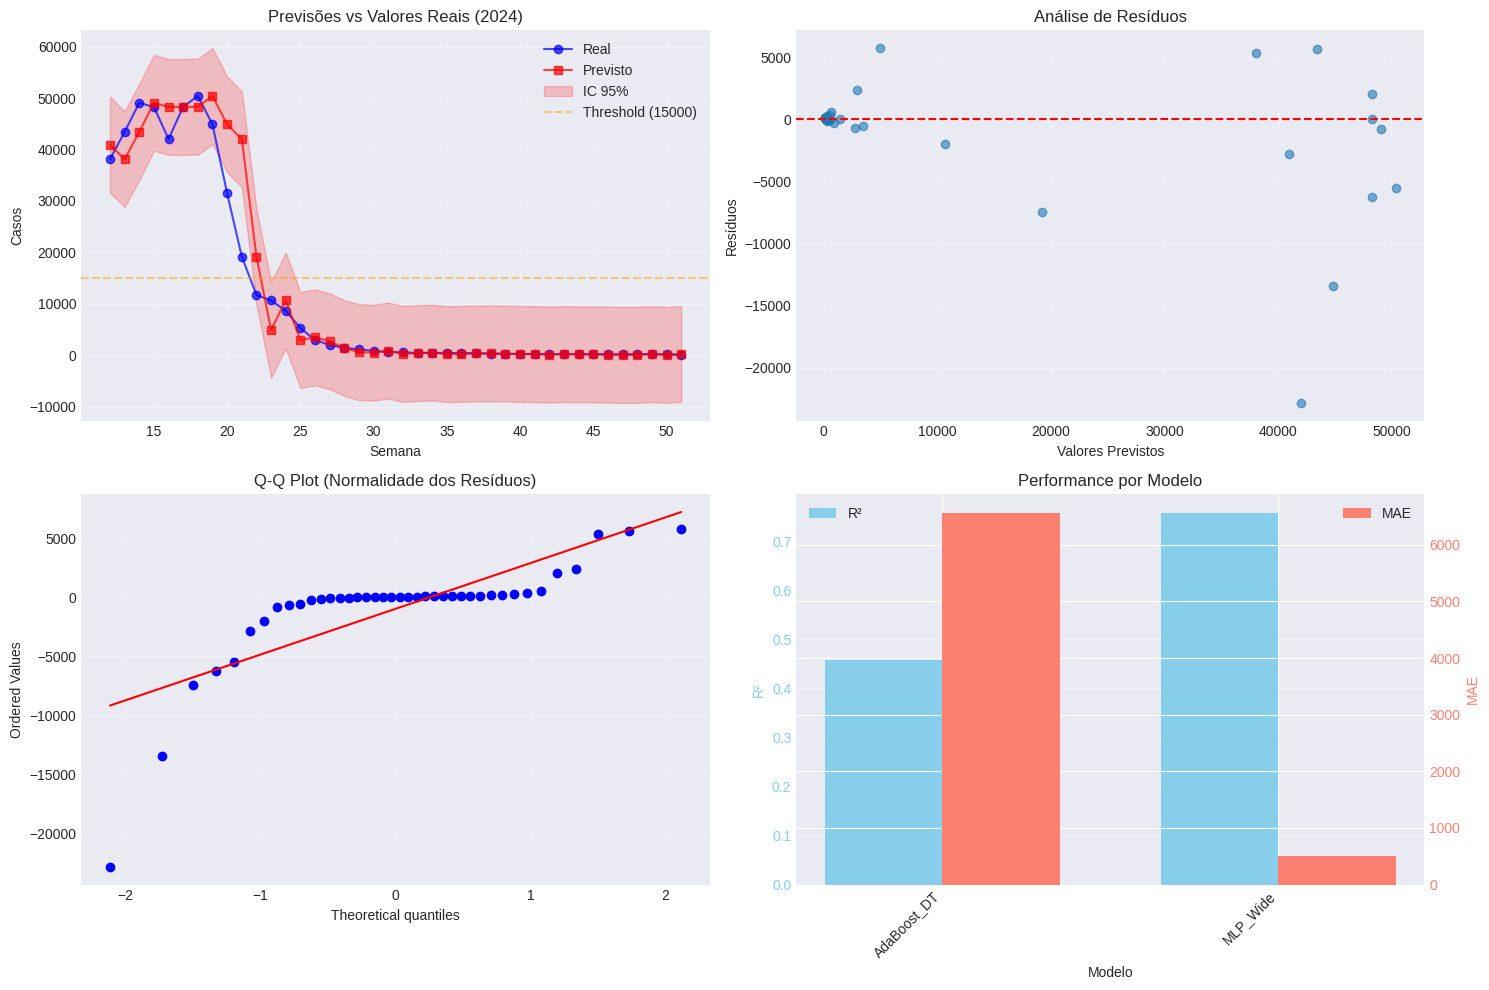

In [ ]:
# ==============================================================================
# VISUALIZAÇÕES
# ==============================================================================

print("\n[7] Gerando visualizações...")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Previsões vs Real
ax1 = axes[0, 0]
ax1.plot(df_eval['semana'], df_eval['real_next'], 'o-', label='Real', color='blue', alpha=0.7)
ax1.plot(df_eval['semana'], df_eval['pred'], 's-', label='Previsto', color='red', alpha=0.7)
ax1.fill_between(df_eval['semana'], df_eval['lower_bound'], df_eval['upper_bound'],
                  alpha=0.2, color='red', label=f'IC {CONFIDENCE_LEVEL*100:.0f}%')
ax1.axhline(y=THRESHOLD, color='orange', linestyle='--', label=f'Threshold ({THRESHOLD})', alpha=0.5)
ax1.set_xlabel('Semana')
ax1.set_ylabel('Casos')
ax1.set_title('Previsões vs Valores Reais (2024)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Resíduos
ax2 = axes[0, 1]
residuals = df_eval['real_next'] - df_eval['pred']
ax2.scatter(df_eval['pred'], residuals, alpha=0.6)
ax2.axhline(y=0, color='red', linestyle='--')
ax2.set_xlabel('Valores Previstos')
ax2.set_ylabel('Resíduos')
ax2.set_title('Análise de Resíduos')
ax2.grid(True, alpha=0.3)

# 3. Q-Q Plot
ax3 = axes[1, 0]
stats.probplot(residuals, dist="norm", plot=ax3)
ax3.set_title('Q-Q Plot (Normalidade dos Resíduos)')
ax3.grid(True, alpha=0.3)

# 4. Performance por Modelo
ax4 = axes[1, 1]
models = df_eval.groupby('modelo').apply(
    lambda x: pd.Series({
        'R²': r2_score(x['real_next'], x['pred']),
        'MAE': mean_absolute_error(x['real_next'], x['pred']),
        'N': len(x)
    })
).reset_index()

x_pos = np.arange(len(models))
width = 0.35

ax4_twin = ax4.twinx()
bars1 = ax4.bar(x_pos - width/2, models['R²'], width, label='R²', color='skyblue')
bars2 = ax4_twin.bar(x_pos + width/2, models['MAE'], width, label='MAE', color='salmon')

ax4.set_xlabel('Modelo')
ax4.set_ylabel('R²', color='skyblue')
ax4_twin.set_ylabel('MAE', color='salmon')
ax4.set_title('Performance por Modelo')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(models['modelo'], rotation=45, ha='right')
ax4.tick_params(axis='y', labelcolor='skyblue')
ax4_twin.tick_params(axis='y', labelcolor='salmon')
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('validacao_modelo_final.png', dpi=300, bbox_inches='tight')
print(f"  ✅ Gráfico salvo: validacao_modelo_final.png")

In [ ]:
# ==============================================================================
# RELATÓRIO FINAL
# ==============================================================================

print("\n" + "="*90)
print("RELATÓRIO FINAL DE VALIDAÇÃO")
print("="*90)

print("\n📊 RESUMO EXECUTIVO:")
print(f"  Modelo: MLP Wide (100,50) + AdaBoost_DT (n=100)")
print(f"  Threshold: {THRESHOLD:,} casos")
print(f"  Período: 2024 (teste)")
print(f"  N previsões: {len(df_eval)}")

print("\n🎯 PERFORMANCE:")
print(f"  R² global: {r2_global:.4f}")
print(f"  MAE global: {mae_global:.2f} casos")
print(f"  RMSE global: {rmse_global:.2f} casos")
print(f"  Intervalo de confiança: ±{margin_error:.2f} casos")
print(f"  Cobertura IC: {coverage:.1f}%")

print("\n✅ VALIDAÇÕES:")
print(f"  [1] Data Leakage: PASS")
print(f"  [2] Overfitting: {overfitting_results['overfitting_score']}")
print(f"      - Degradação R²: {overfitting_results['degradacao_r2']:.1f}%")
print(f"  [3] Cross-Validation: {len(cv_results)} folds validados")
print(f"  [4] Resíduos:")
print(f"      - Média: {residual_results['mean']:.2f} (próximo de 0 ✅)")
print(f"      - Autocorrelação: {residual_results['autocorr']:.4f}")
print(f"  [5] Intervalos: {coverage:.1f}% cobertura")
print(f"  [6] Por Contexto:")
if context_results['r2_normal']:
    print(f"      - Normal: R²={context_results['r2_normal']:.4f}, MAE={context_results['mae_normal']:.2f}")
if context_results['r2_surto']:
    print(f"      - Surto: R²={context_results['r2_surto']:.4f}, MAE={context_results['mae_surto']:.2f}")

print("\n⚠️ LIMITAÇÕES:")
print(f"  - R² em surto isolado: {context_results['r2_surto']:.4f} (moderado)")
print(f"  - Surtos são intrinsecamente difíceis de prever")
print(f"  - Apenas {len(df_eval[df_eval['casos_atual'] > THRESHOLD])} semanas de surto em 2024")
print(f"  - Modelo depende de dados de treino recentes")


RELATÓRIO FINAL DE VALIDAÇÃO

📊 RESUMO EXECUTIVO:
  Modelo: MLP Wide (100,50) + AdaBoost_DT (n=100)
  Threshold: 15,000 casos
  Período: 2024 (teste)
  N previsões: 40

🎯 PERFORMANCE:
  R² global: 0.9276
  MAE global: 2164.94 casos
  RMSE global: 4856.40 casos
  Intervalo de confiança: ±9321.16 casos
  Cobertura IC: 95.0%

✅ VALIDAÇÕES:
  [1] Data Leakage: PASS
  [2] Overfitting: BAIXO
      - Degradação R²: 98.7%
  [3] Cross-Validation: 5 folds validados
  [4] Resíduos:
      - Média: -983.44 (próximo de 0 ✅)
      - Autocorrelação: 0.5073
  [5] Intervalos: 95.0% cobertura
  [6] Por Contexto:
      - Normal: R²=0.7582, MAE=496.78
      - Surto: R²=0.4585, MAE=6562.82

⚠️ LIMITAÇÕES:
  - R² em surto isolado: 0.4585 (moderado)
  - Surtos são intrinsecamente difíceis de prever
  - Apenas 11 semanas de surto em 2024
  - Modelo depende de dados de treino recentes
